In [3]:
libraries = c("dplyr", "tidyverse", "magrittr", "ggplot2")
for(x in libraries) {library(x,character.only = TRUE, warn.conflicts = FALSE, quietly = TRUE)}
theme_set(theme_bw())

In [4]:
source("settings_for_simulations.r")

# Cohort-based simulation for generating seroprevalence data

In [5]:
sero_sim_grouped <- function(foi, ifr, n_yrs, n0 = n_sus) {

    group_num <- ceiling(n_yrs / 10)
     
    age_lower <- (0:(group_num - 1)) * 10
    age_upper <- pmin((1:group_num) * 10, n_yrs)
    w <- age_upper - age_lower
    
    C_obs <- n0; A_obs <- 0; D_obs <- 0; C_true <- n0; A_true <- 0
    
    out <- data.frame(age_group = 1:group_num, age_lower = age_lower, age_upper = age_upper,
                      Observed = NA_real_, True = NA_real_, n_dead = NA_real_, alive = NA_real_)

    for (g in 1:group_num) {
        lam <- foi[g]; f <- ifr[g]; wi <- w[g]
      
        x <- lam * wi
        uw <- exp(-x)
        one_minus_uw <- -expm1(-x)
      
        denom_true <- A_true + C_true
        True_binavg <- 1 - (C_true / denom_true) * (one_minus_uw / x)

        denom0 <- A_obs + C_obs
        denom1 <- A_obs + C_obs * (1 - f) + C_obs * f * uw
        log_ratio <- -log1p((denom1 - denom0) / denom0)
        Obs_binavg <- 1 - (1 / (x * f)) * log_ratio

        out$Observed[g] <- Obs_binavg
        out$True[g] <- True_binavg
        out$n_dead[g] <- D_obs
        out$alive[g] <- (A_obs + C_obs)

        ## True seroprevalence
        new_inf_true <- C_true * one_minus_uw
        C_true <- C_true * uw
        A_true <- A_true + new_inf_true
        
        # Observed seroprevalence
        new_inf_obs <- C_obs * one_minus_uw
        new_dead_obs <- new_inf_obs * f
        new_imm_obs <- new_inf_obs * (1 - f)
        
        C_obs <- C_obs * uw
        A_obs <- A_obs + new_imm_obs
        D_obs <- D_obs + new_dead_obs
    }
    out
}

# Differences between true and observed seroprevlaence (age-constant FoI)

In [6]:
temp_all <- data.frame()
for (i in seq_along(target_foi)) {
    for (l in seq_along(target_IFR)) {
        for (g in seq_along(IFR_class)) {
            foi_profile <- foi_profile_list[[i]]
            ifr_profile <- ifr_profile_scale_list[[g]][[l]]
            sero_sim_grouped(foi = foi_profile, ifr = ifr_profile, n_yrs = age_limit) %>%
            mutate(age_group = age_group * 10,
                   bias_ratio = if_else(True > 0, (1 - Observed/True) * 100, NA_real_),
                   bias_diff = (True - Observed) *100,
                   scenario = paste0(IFR_class[g]),
                   ifr_level = paste0("IFR (", target_IFR[l], "%)"),
                   foi_level = paste0("Age-constant FoI (", target_foi[i], "%)")) -> temp

            temp_all <- bind_rows(temp_all, temp)
        }
    }
}

temp_all$ifr_level <- factor(temp_all$ifr_level, levels = c(paste0("IFR (",target_IFR[4], "%)"),
                                                            paste0("IFR (",target_IFR[3], "%)"),
                                                            paste0("IFR (",target_IFR[2], "%)"),
                                                            paste0("IFR (",target_IFR[1], "%)")))
temp_all$scenario <- factor(temp_all$scenario, levels = c("Decreasing IFR", "U-shaped IFR", "Increasing IFR"))

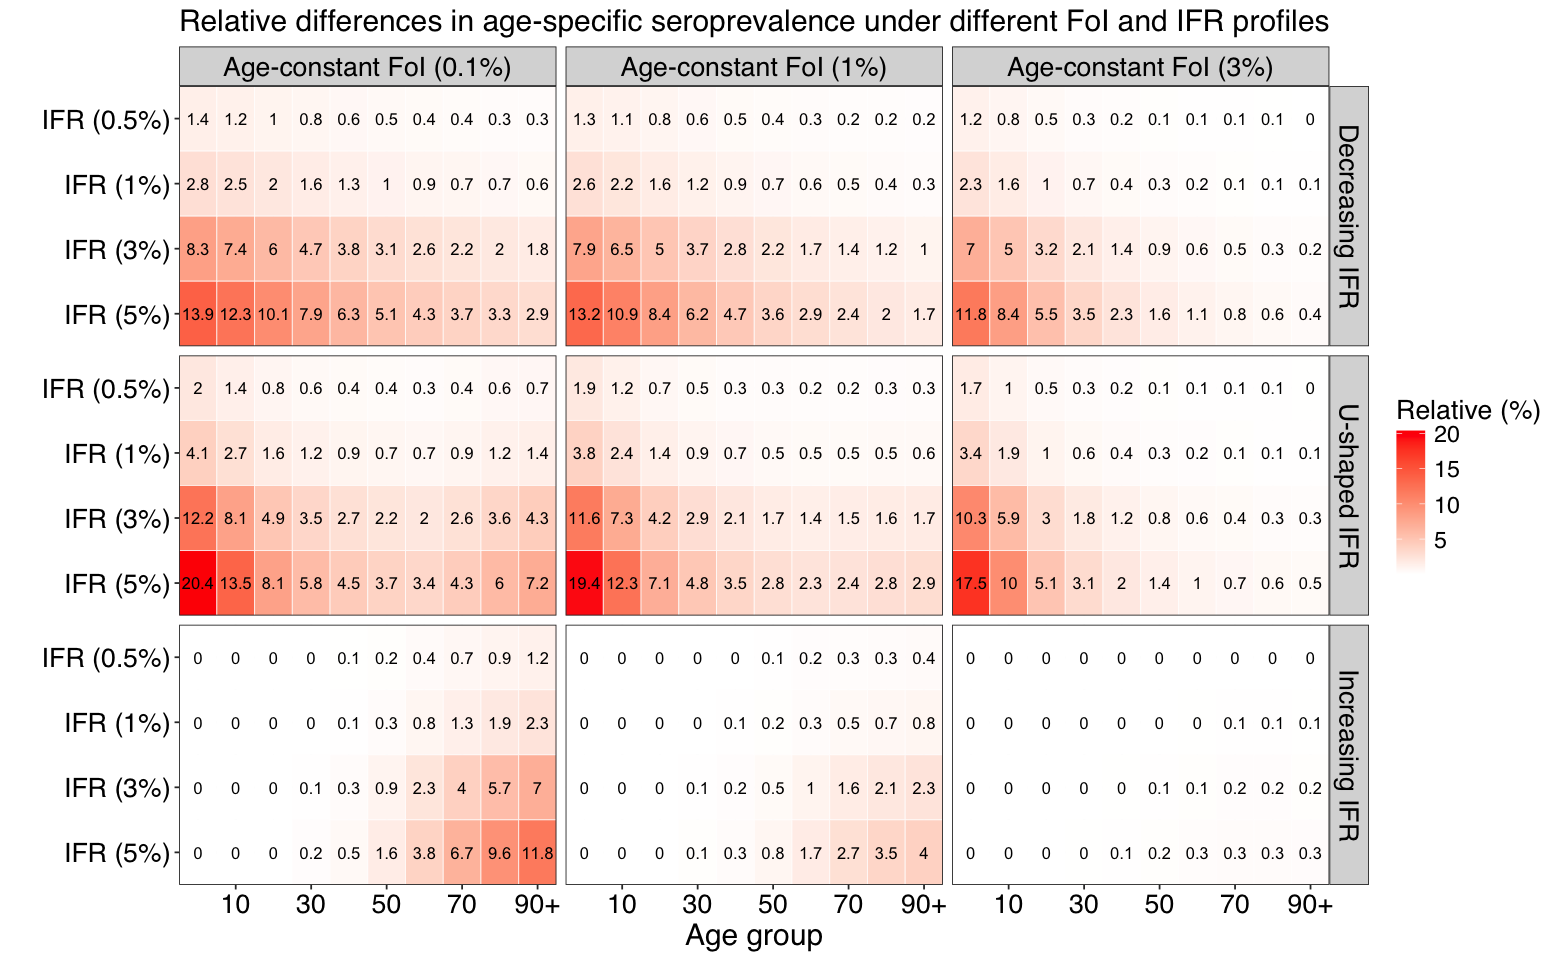

In [7]:
## plotting relative differences between true and observed seroprevalence
options(repr.plot.width = 13, repr.plot.height = 8)

temp_all %>% mutate(age_group_num = if_else(age_group < 100, age_group - 10, 90)) %>% 
ggplot(aes(x = age_group_num, y = ifr_level, fill = bias_ratio)) +
geom_tile(color = "white") +
geom_text(aes(label = round(bias_ratio, 1)), size = 3.5, color = "black") +
facet_grid(scenario ~ foi_level) +
scale_fill_gradient2(low = "blue", mid = "white", high = "red", name = "Relative (%)") +
scale_x_continuous(expand = c(0, 0), breaks = c(10, 30, 50, 70, 90), labels = c("10", "30", "50", "70", "90+")) +
scale_y_discrete(expand = c(0, 0)) +
ggtitle("Relative differences in age-specific seroprevalence under different FoI and IFR profiles") +
labs(x = "Age group", y = "") +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 16, family = "sans", color = "black"),
      legend.title = element_text(size = 16, color = "black"),
      legend.text = element_text(size = 14, color = "black"),
      plot.title = element_text(size = 18, family = "sans", color = "black"), 
      strip.text = element_text(size = 16, family = "sans", color = "black"))

ggsave("figures/heatmap_const_rel.png", width = 13, height = 8, dpi = 300, bg = "white")

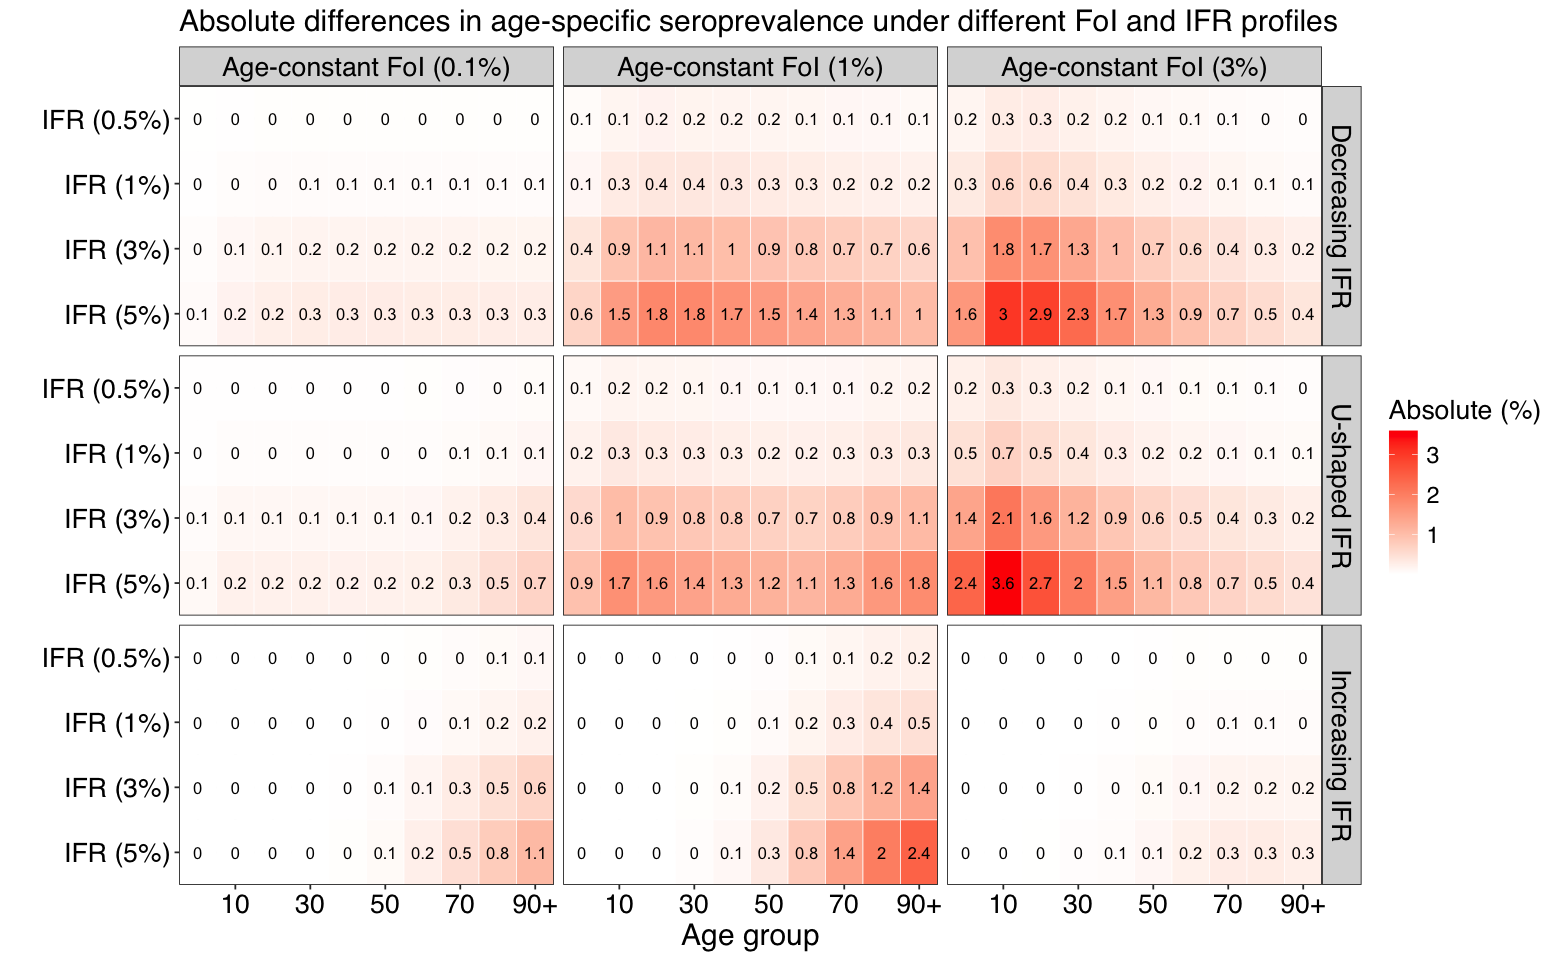

In [8]:
## plotting absolute differences between true and observed seroprevalence
options(repr.plot.width = 13, repr.plot.height = 8)

temp_all %>% mutate(age_group_num = if_else(age_group < 100, age_group - 10, 90)) %>% 
ggplot(aes(x = age_group_num, y = ifr_level, fill = bias_diff)) +
geom_tile(color = "white") +
geom_text(aes(label = round(bias_diff, 1)), size = 3.5, color = "black") +
facet_grid(scenario ~ foi_level) +
scale_fill_gradient2(low = "blue", mid = "white", high = "red", name = "Absolute (%)") +
scale_x_continuous(expand = c(0, 0), breaks = c(10, 30, 50, 70, 90), labels = c("10", "30", "50", "70", "90+")) +
scale_y_discrete(expand = c(0, 0)) +
ggtitle("Absolute differences in age-specific seroprevalence under different FoI and IFR profiles") +
labs(x = "Age group", y = "") +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 16, family = "sans", color = "black"),
      legend.title = element_text(size = 16, color = "black"),
      legend.text = element_text(size = 14, color = "black"),
      plot.title = element_text(size = 18, family = "sans", color = "black"), 
      strip.text = element_text(size = 16, family = "sans", color = "black"))

ggsave("figures/heatmap_const_abs.png", width = 13, height = 8, dpi = 300, bg = 'white')

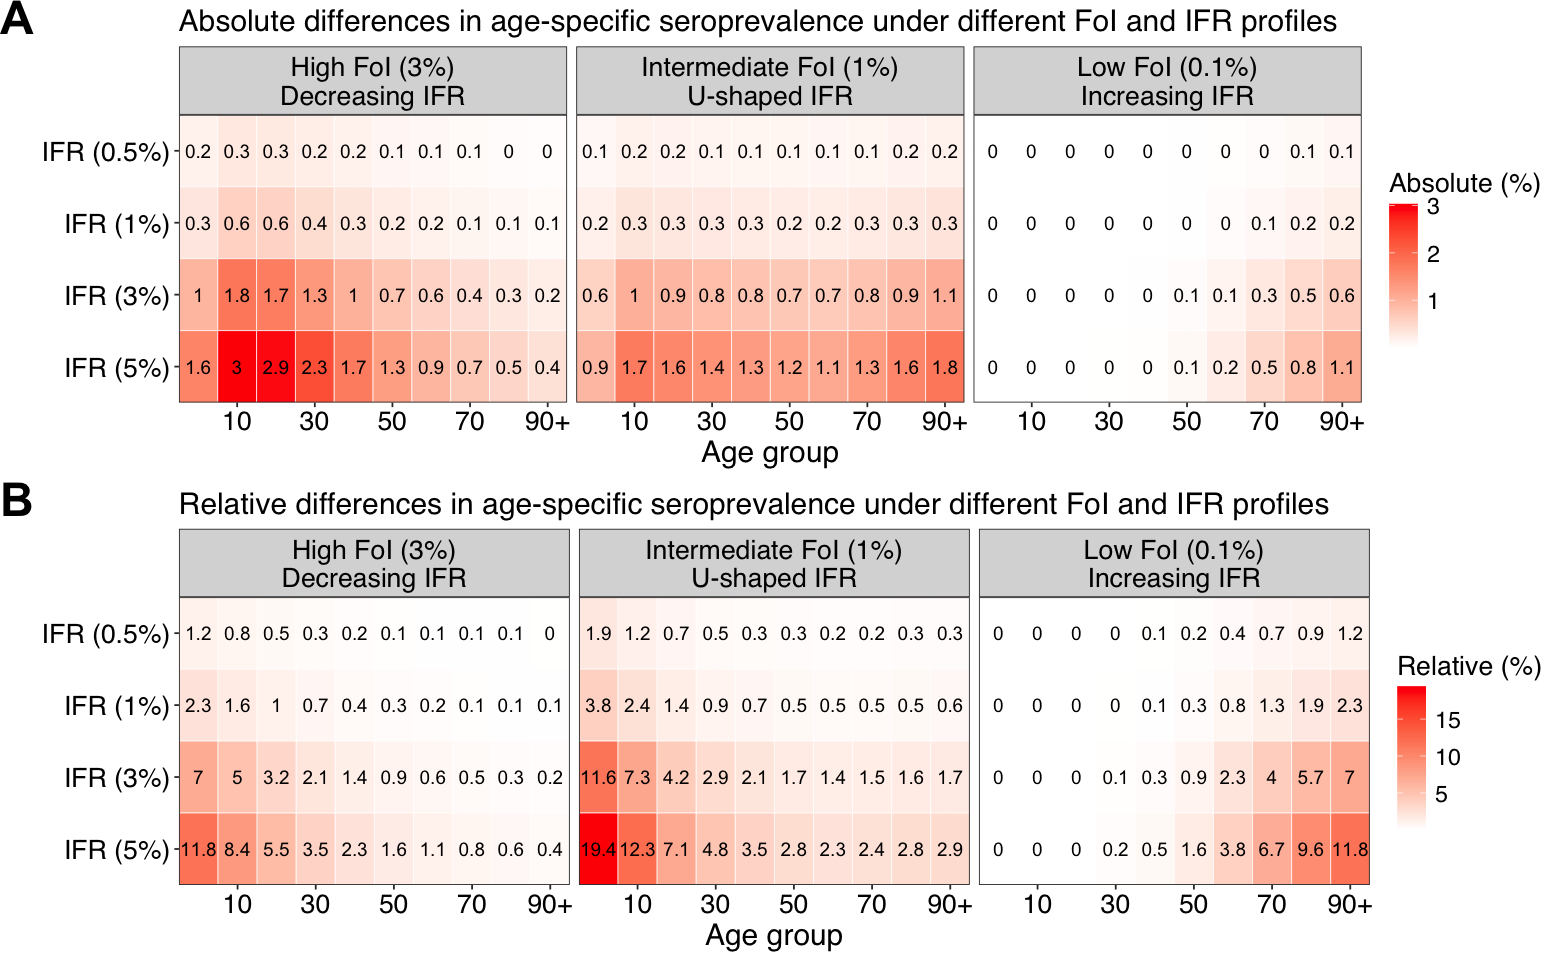

In [9]:
## plot for papers
temp_all %>% 
filter((scenario == "Decreasing IFR" & foi_level == paste0("Age-constant FoI (", target_foi[3], "%)")) |
       (scenario == "U-shaped IFR" & foi_level == paste0("Age-constant FoI (", target_foi[2], "%)")) |
       (scenario == "Increasing IFR" & foi_level == paste0("Age-constant FoI (", target_foi[1], "%)"))) %>%
mutate(scenario_label = case_when(scenario == "Decreasing IFR" ~ paste0("High FoI (", target_foi[3], "%)\nDecreasing IFR"),
                                  scenario == "U-shaped IFR" ~ paste0("Intermediate FoI (", target_foi[2], "%)\nU-shaped IFR"),
                                  scenario == "Increasing IFR" ~ paste0("Low FoI (", target_foi[1], "%)\nIncreasing IFR"), TRUE ~ scenario),
       scenario_label = factor(scenario_label, levels = c(paste0("High FoI (", target_foi[3], "%)\nDecreasing IFR"),
                                                          paste0("Intermediate FoI (", target_foi[2], "%)\nU-shaped IFR"),
                                                          paste0("Low FoI (", target_foi[1], "%)\nIncreasing IFR")))) -> df_figure

options(repr.plot.width = 13, repr.plot.height = 4)

df_figure %>% mutate(age_group_num = if_else(age_group < 100, age_group - 10, 90)) %>% 
ggplot(aes(x = age_group_num, y = ifr_level, fill = bias_ratio)) +
geom_tile(color = "white") +
geom_text(aes(label = round(bias_ratio, 1)), size = 4, color = "black") +
facet_grid(~ scenario_label) +
scale_fill_gradient2(low = "blue", mid = "white", high = "red", name = "Relative (%)") +
scale_x_continuous(expand = c(0, 0), breaks = c(10, 30, 50, 70, 90), labels = c("10", "30", "50", "70", "90+")) +
scale_y_discrete(expand = c(0, 0)) +
ggtitle("Relative differences in age-specific seroprevalence under different FoI and IFR profiles") +
labs(x = "Age group", y = "") +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 16, family = "sans", color = "black"),
      legend.title = element_text(size = 16, color = "black"),
      legend.text = element_text(size = 14, color = "black"),
      plot.title = element_text(size = 18, family = "sans", color = "black"), 
      strip.text = element_text(size = 16, family = "sans", color = "black")) -> rel_fig

df_figure %>% mutate(age_group_num = if_else(age_group < 100, age_group - 10, 90)) %>% 
ggplot(aes(x = age_group_num, y = ifr_level, fill = bias_diff)) +
geom_tile(color = "white") +
geom_text(aes(label = round(bias_diff, 1)), size = 4, color = "black") +
facet_grid(~ scenario_label) +
scale_fill_gradient2(low = "blue", mid = "white", high = "red", name = "Absolute (%)") +
scale_x_continuous(expand = c(0, 0), breaks = c(10, 30, 50, 70, 90), labels = c("10", "30", "50", "70", "90+")) +
scale_y_discrete(expand = c(0, 0)) +
ggtitle("Absolute differences in age-specific seroprevalence under different FoI and IFR profiles") +
labs(x = "Age group", y = "") +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 16, family = "sans", color = "black"),
      legend.title = element_text(size = 16, color = "black"),
      legend.text = element_text(size = 14, color = "black"),
      plot.title = element_text(size = 18, family = "sans", color = "black"), 
      strip.text = element_text(size = 16, family = "sans", color = "black")) -> abs_fig

options(repr.plot.width = 13, repr.plot.height = 8)
ggpubr::ggarrange(abs_fig, ggplot() + theme_void(), rel_fig, heights = c(1, 0.01, 1), ncol = 1, nrow = 3, 
                  labels = c("A", "", "B"), font.label = list(size = 28), vjust = 1, hjust = 0)

ggsave("figures/heatmap_const.png", width = 13, height = 8, dpi = 300, bg = 'white')

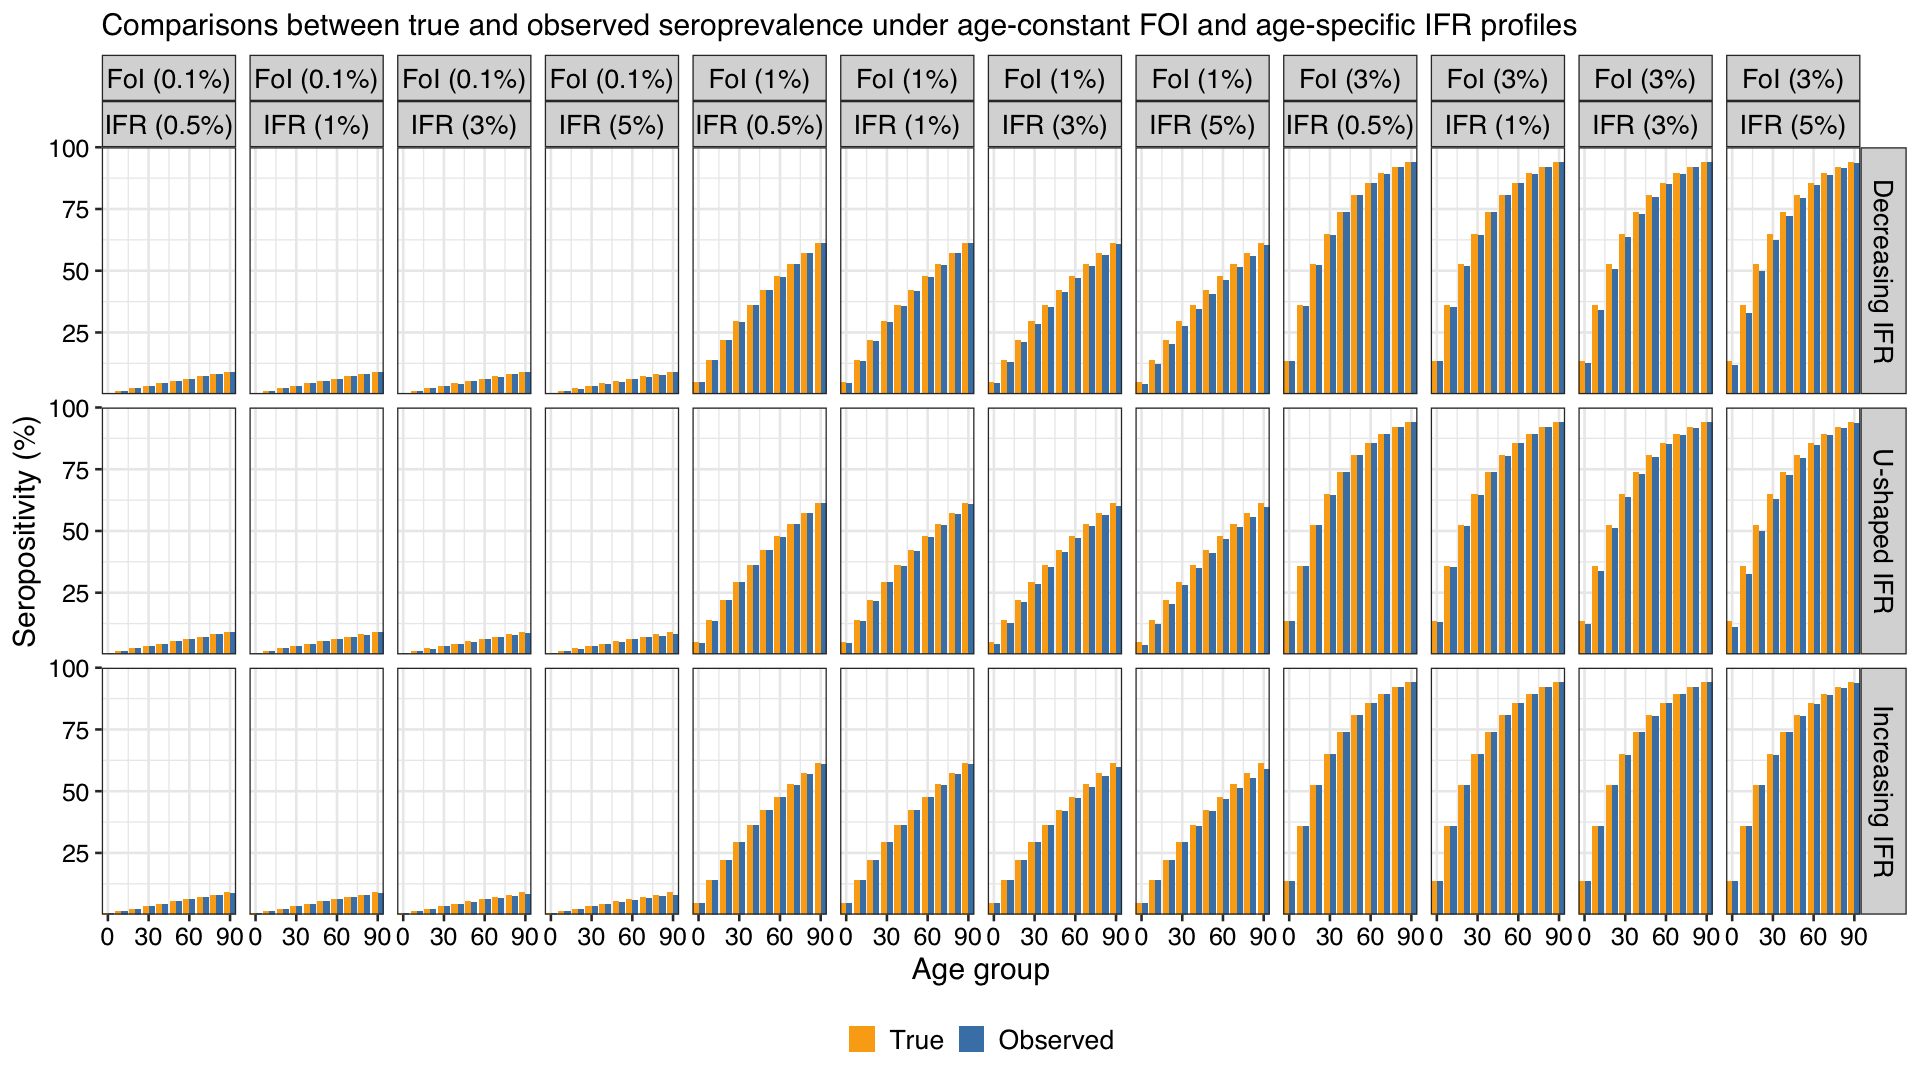

In [10]:
## plotting true and observed seroprevalence by IFR and FoI profile
plot_data <- data.frame()

for (i in seq_along(target_foi)) {
    for (l in seq_along(target_IFR)) {
        for (g in seq_along(IFR_class)) {
            
            foi_profile <- foi_profile_list[[i]]
            ifr_profile <- ifr_profile_scale_list[[g]][[l]]
      
            temp <- sero_sim_grouped(foi = foi_profile, ifr = ifr_profile, n_yrs = age_limit) %>%
            mutate(age_group = age_group * 10, scenario = IFR_class[g], 
                   foi_level = paste0("FoI (", target_foi[i], "%)"), 
                   ifr_level = paste0("IFR (", target_IFR[l], "%)")) %>%
            dplyr::select(age_group, Observed, True, scenario, foi_level, ifr_level) %>%
            tidyr::pivot_longer(cols = c("Observed", "True"), names_to = "Group", values_to = "prev")
      
            plot_data <- bind_rows(plot_data, temp)
        }
    }
}

plot_data$Group = factor(plot_data$Group, levels = c("True", "Observed"))
plot_data$scenario <- factor(plot_data$scenario, levels = c("Decreasing IFR", "U-shaped IFR", "Increasing IFR"))
plot_data$ifr_level <- factor(plot_data$ifr_level, levels = c(paste0("IFR (", target_IFR[1], "%)"),
                                                              paste0("IFR (", target_IFR[2], "%)"),
                                                              paste0("IFR (", target_IFR[3], "%)"),
                                                              paste0("IFR (", target_IFR[4], "%)")))

options(repr.plot.width = 16, repr.plot.height = 9)

ggplot(plot_data, aes(x = age_group, y = prev * 100, fill = Group)) +
geom_bar(stat = "identity", position = "dodge") +
facet_grid(scenario ~ foi_level + ifr_level) +
scale_fill_manual("", values = c("True" = "#FAAB18", "Observed" = "steelblue")) +
scale_x_continuous(expand = c(0, 0), breaks = c(10, 40, 70, 100), labels = c("0", "30", "60", "90")) +
scale_y_continuous(limits = c(0, 100), expand = c(0, 0), breaks = c(25, 50, 75, 100)) +
labs(x = "Age group", y = "Seropositivity (%)") +
ggtitle("Comparisons between true and observed seroprevalence under age-constant FOI and age-specific IFR profiles") +
theme_bw(base_size = 16) +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 15, family = "sans", color = "black"),
      legend.title = element_blank(), legend.position = "bottom",
      legend.text = element_text(size = 16, color = "black"),
      plot.title = element_text(size = 18, family = "sans", color = "black"), 
      strip.text = element_text(size = 16, family = "sans", color = "black"))

ggsave("figures/seroprev_facetgrid_supplementary.png", width = 16, height = 9, dpi = 300, bg = "white")

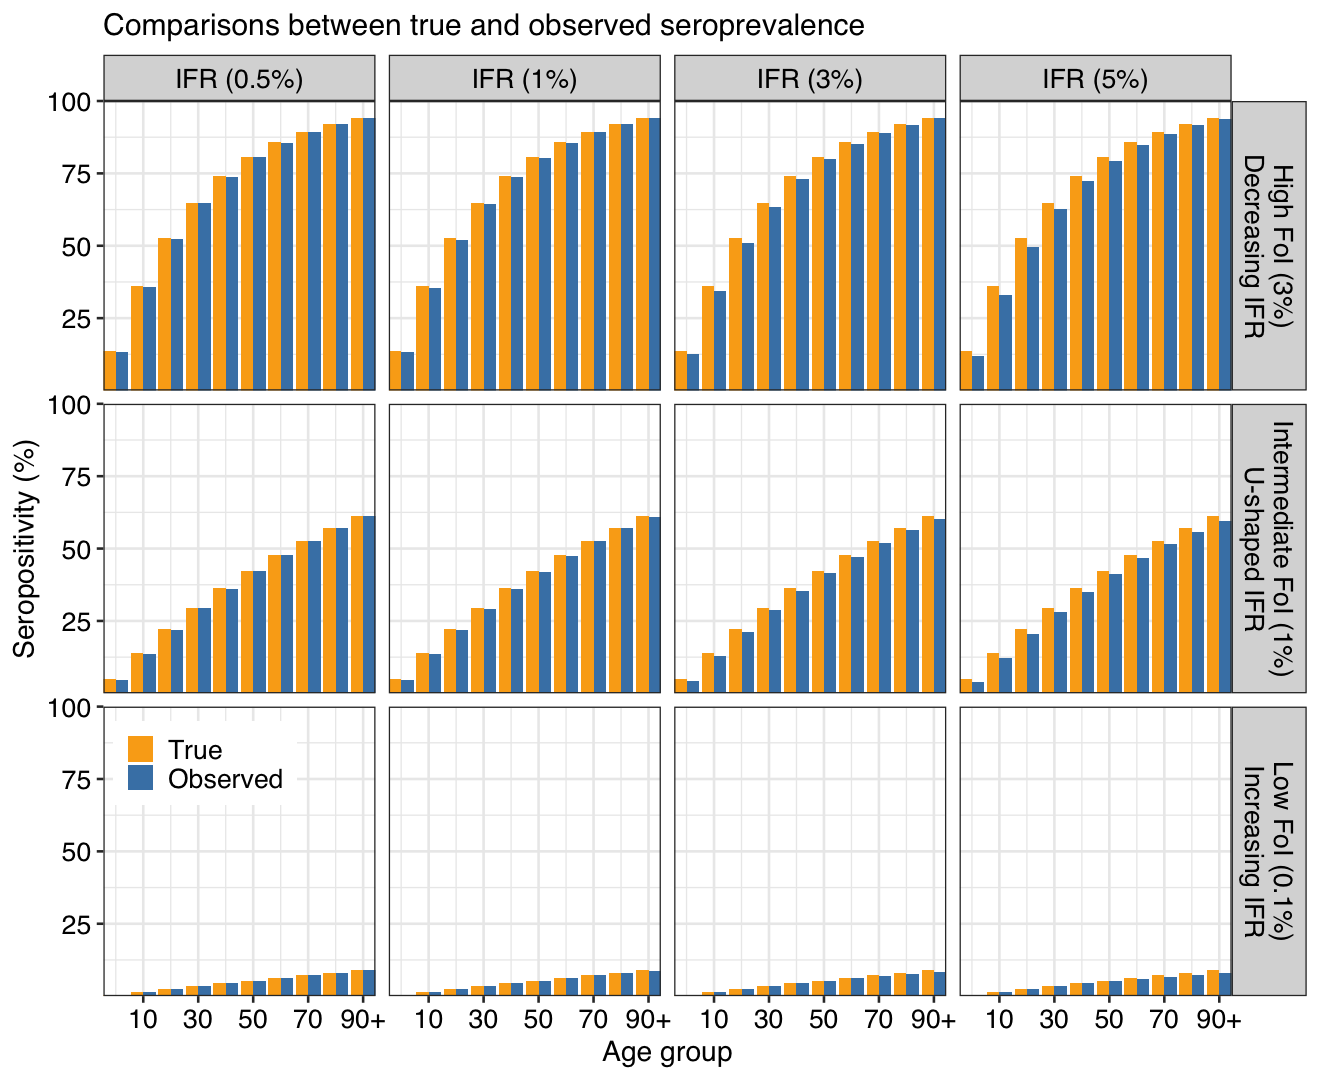

In [16]:
## plotting three realistic examples
plot_data <- expand.grid(i = seq_along(target_foi), l = seq_along(target_IFR), g = seq_along(IFR_class)) %>% 
purrr::pmap_dfr(function(i, l, g) {
    foi_profile <- foi_profile_list[[i]]
    ifr_profile <- ifr_profile_scale_list[[g]][[l]]

    sero_sim_grouped(foi = foi_profile, ifr = ifr_profile, n_yrs = age_limit) %>%
    mutate(age_group = age_group * 10, scenario = IFR_class[g], 
           foi_level  = paste0("FoI (", target_foi[i], "%)"),
           ifr_level  = paste0("IFR (", target_IFR[l], "%)")) %>%
    dplyr::select(age_group, Observed, True, scenario, foi_level, ifr_level) %>%
    tidyr::pivot_longer(cols = c("Observed", "True"), names_to = "Group", values_to = "prev")})

plot_data %<>% 
mutate(Group = factor(Group, levels = c("True", "Observed")),
       scenario = factor(scenario, levels = c("Decreasing IFR", "U-shaped IFR", "Increasing IFR")),
       ifr_level = factor(ifr_level, levels = paste0("IFR (", target_IFR, "%)"))) %>%
filter((scenario == "Decreasing IFR" & foi_level == paste0("FoI (", target_foi[3], "%)")) |
       (scenario == "U-shaped IFR" & foi_level == paste0("FoI (", target_foi[2], "%)")) |
       (scenario == "Increasing IFR" & foi_level == paste0("FoI (", target_foi[1], "%)"))) %>%
mutate(scenario_label = case_when(scenario == "Decreasing IFR" ~ paste0("High FoI (", target_foi[3], "%)\nDecreasing IFR"),
                                  scenario == "U-shaped IFR" ~ paste0("Intermediate FoI (", target_foi[2], "%)\nU-shaped IFR"),
                                  scenario == "Increasing IFR" ~ paste0("Low FoI (", target_foi[1], "%)\nIncreasing IFR"), TRUE ~ scenario),
       scenario_label = factor(scenario_label, levels = c(paste0("High FoI (", target_foi[3], "%)\nDecreasing IFR"),
                                                          paste0("Intermediate FoI (", target_foi[2], "%)\nU-shaped IFR"),
                                                          paste0("Low FoI (", target_foi[1], "%)\nIncreasing IFR"))))
       
options(repr.plot.width = 11, repr.plot.height = 9)

ggplot(plot_data, aes(x = age_group, y = prev * 100, fill = Group)) +
geom_bar(stat = "identity", position = "dodge") +
facet_grid(scenario_label ~ ifr_level) +
scale_fill_manual("", values = c("True" = "#FAAB18", "Observed" = "steelblue")) +
scale_x_continuous(expand = c(0, 0), breaks = c(20, 40, 60, 80, 100), labels = c("10", "30", "50", "70", "90+")) +
scale_y_continuous(limits = c(0, 100), expand = c(0, 0), breaks = c(25, 50, 75, 100)) +
labs(x = "Age group", y = "Seropositivity (%)") +
ggtitle("Comparisons between true and observed seroprevalence") +
theme_bw(base_size = 16) +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 16, family = "sans", color = "black"),
      axis.title = element_text(size = 17, family = "sans", color = "black"),
      legend.position = "inside", legend.position.inside = c(0.09, 0.26),
      legend.text = element_text(size = 16, color = "black"), legend.title = element_blank(), 
      plot.title = element_text(size = 18, family = "sans", color = "black"), 
      strip.text = element_text(size = 16, family = "sans", color = "black")) 

ggsave("figures/seroprev_facetgrid_main.png", width = 11, height = 9, dpi = 300, bg = "white")

In [17]:
## plot for papers
df_figure %>% mutate(age_group_num = if_else(age_group < 100, age_group - 10, 90)) %>% 
ggplot(aes(x = age_group_num, y = ifr_level, fill = bias_ratio)) +
geom_tile(color = "white") +
geom_text(aes(label = round(bias_ratio, 1)), size = 3.5, color = "black") +
facet_grid(~ scenario_label) +
scale_fill_gradient2(low = "blue", mid = "white", high = "red", name = "Relative (%)") +
scale_x_continuous(expand = c(0, 0), breaks = c(10, 30, 50, 70, 90), labels = c("10", "30", "50", "70", "90+")) +
scale_y_discrete(expand = c(0, 0)) +
ggtitle("Relative differences in age group-specific seroprevalence") +
labs(x = "Age group", y = "") +
theme(text = element_text(size = 14, family = "sans", color = "black"),
      axis.text = element_text(size = 14, family = "sans", color = "black"),
      legend.title = element_text(size = 15, color = "black"),
      legend.text = element_text(size = 14, color = "black"),
      plot.title = element_text(size = 17, family = "sans", color = "black"), 
      strip.text = element_text(size = 15, family = "sans", color = "black")) -> rel_fig

df_figure %>% mutate(age_group_num = if_else(age_group < 100, age_group - 10, 90)) %>% 
ggplot(aes(x = age_group_num, y = ifr_level, fill = bias_diff)) +
geom_tile(color = "white") +
geom_text(aes(label = round(bias_diff, 1)), size = 3.5, color = "black") +
facet_grid(~ scenario_label) +
scale_fill_gradient2(low = "blue", mid = "white", high = "red", name = "Absolute (%)") +
scale_x_continuous(expand = c(0, 0), breaks = c(10, 30, 50, 70, 90), labels = c("10", "30", "50", "70", "90+")) +
scale_y_discrete(expand = c(0, 0)) +
ggtitle("Absolute differences in age group-specific seroprevalence") +
labs(x = "Age group", y = "") +
theme(text = element_text(size = 14, family = "sans", color = "black"),
      axis.text = element_text(size = 14, family = "sans", color = "black"),
      legend.title = element_text(size = 15, color = "black"),
      legend.text = element_text(size = 14, color = "black"),
      plot.title = element_text(size = 17, family = "sans", color = "black"), 
      strip.text = element_text(size = 15, family = "sans", color = "black")) -> abs_fig

ggplot(plot_data, aes(x = age_group, y = prev * 100, fill = Group)) +
geom_bar(stat = "identity", position = "dodge") +
facet_grid(scenario_label ~ ifr_level) +
scale_fill_manual("", values = c("True" = "#FAAB18", "Observed" = "steelblue")) +
scale_x_continuous(expand = c(0, 0), breaks = c(20, 40, 60, 80, 100), labels = c("10", "30", "50", "70", "90+")) +
scale_y_continuous(limits = c(0, 100), expand = c(0, 0), breaks = c(25, 50, 75, 100)) +
labs(x = "Age group", y = "Seropositivity (%)") +
ggtitle("Comparisons between true and observed seroprevalence") +
theme(text = element_text(size = 14, family = "sans", color = "black"),
      axis.text = element_text(size = 14, family = "sans", color = "black"),
      legend.position = "inside", legend.position.inside = c(.1, 0.26),
      legend.text = element_text(size = 15, color = "black"), legend.title = element_blank(), 
      plot.title = element_text(size = 17, family = "sans", color = "black"), 
      strip.text = element_text(size = 15, family = "sans", color = "black")) -> comp_bar

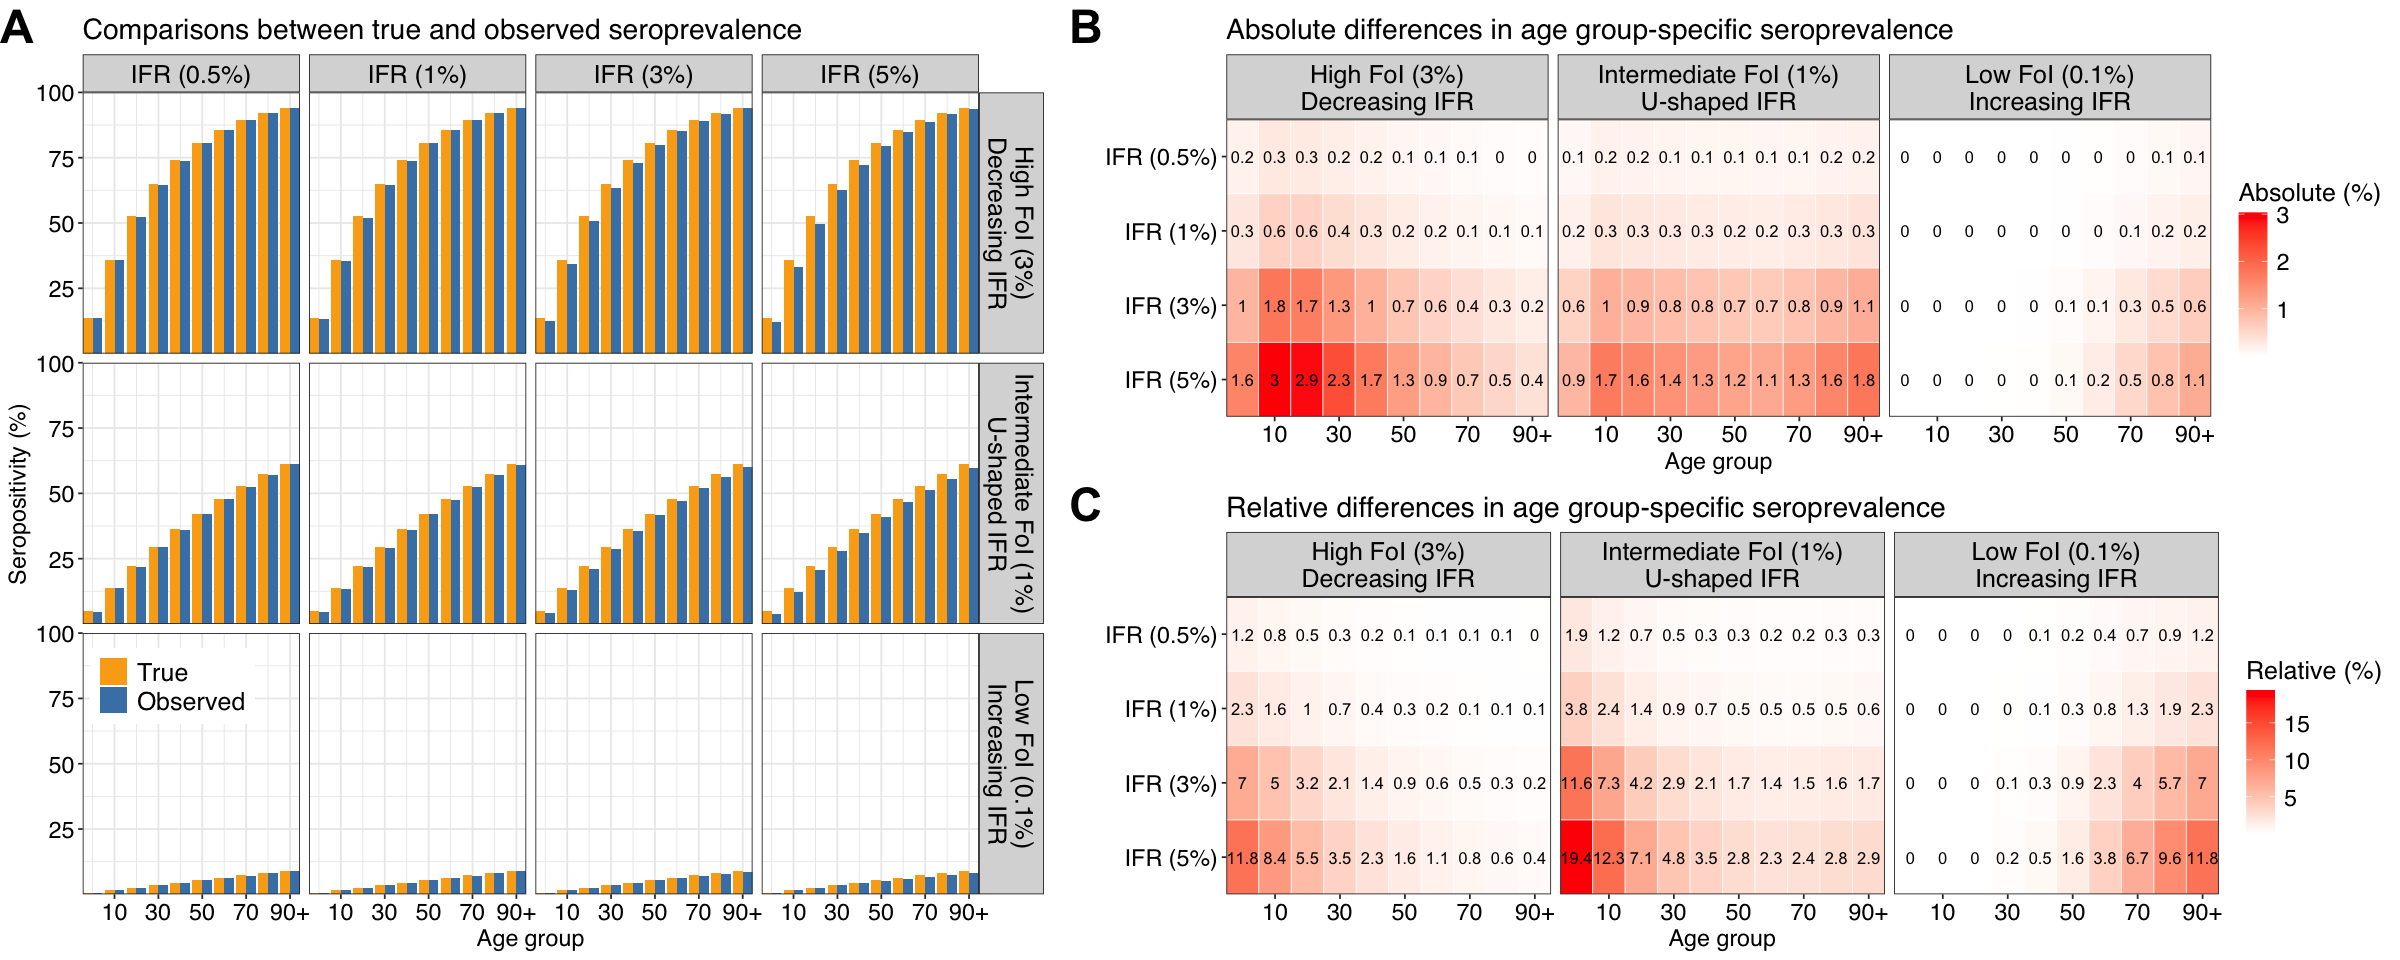

In [18]:
ggpubr::ggarrange(abs_fig, ggplot() + theme_void(), rel_fig, heights = c(1, 0.01, 1), ncol = 1, nrow = 3, 
                  labels = c("B", "", "C"), font.label = list(size = 28), vjust = 1, hjust = 0) -> comp_heat

options(repr.plot.width = 20, repr.plot.height = 8)
ggpubr::ggarrange(ggplot() + theme_void(), ggplot() + theme_void(), ggplot() + theme_void(),
                  comp_bar, ggplot() + theme_void(), comp_heat, 
                  heights = c(.01, 1), widths = c(.95, .015, 1.2), nrow = 2, ncol = 3, 
                  labels = c("", "", "", "A", "", ""), font.label = list(size = 28), vjust = 1, hjust = 0)

ggsave("figures/seroprev_comp_main.png", width = 20, height = 8, dpi = 300, bg = "white")

In [19]:
system("jupyter nbconvert --to script seroprev_constant_FoI_comparison.ipynb")